In [1]:
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SeparableConv2D, BatchNormalization, ReLU
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input

def arduino_cnn(input_shape=(32, 32, 3), nclasses=10):
    model = Sequential()
    model.add(Input(shape=input_shape))

    model.add(SeparableConv2D(24, (3, 3), strides=1, padding='same'))
    model.add(BatchNormalization())
    model.add(ReLU())

    model.add(SeparableConv2D(48, (3, 3), strides=2, padding='same'))
    model.add(BatchNormalization())
    model.add(ReLU())

    model.add(SeparableConv2D(64, (3, 3), strides=2, padding='same'))
    model.add(BatchNormalization())
    model.add(ReLU())

    model.add(GlobalAveragePooling2D())
    model.add(Dense(48, activation='relu'))
    model.add(Dense(nclasses, activation='softmax'))

    return model

In [4]:
model = arduino_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 32, 32, 24)     │           123 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 16, 16, 48)     │         1,416 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 48)     │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 8, 8, 64)       │         3,568 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,261 (36.18 KB)

 Trainable params: 8,989 (35.11 KB)

 Non-trainable params: 272 (1.06 KB)

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# Normalize and augment training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

# Only normalize test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Flow datasets through the generators
train_generator = train_datagen.flow(x_train, y_train_cat, batch_size=64)
test_generator = test_datagen.flow(x_test, y_test_cat, batch_size=64)


In [6]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                 patience=3,
                                 factor=0.5,
                                 min_lr=1e-5)

early_stop = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=30,
    callbacks=[lr_reduction, early_stop],
    verbose=1
)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.2917 - loss: 1.9097 - val_accuracy: 0.3933 - val_loss: 1.6603 - learning_rate: 0.0010
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.4444 - loss: 1.5154 - val_accuracy: 0.4140 - val_loss: 1.6478 - learning_rate: 0.0010
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.4920 - loss: 1.3994 - val_accuracy: 0.4107 - val_loss: 1.6174 - learning_rate: 0.0010
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.5170 - loss: 1.3360 - val_accuracy: 0.4497 - val_loss: 1.6006 - learning_rate: 0.0010
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.5345 - loss: 1.2915 - val_accuracy: 0.3921 - val_loss: 1.9470 - learning_rate: 0.0010
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step - accuracy: 0.5403 - loss: 1.2675 - val_accuracy: 0.4555 - val_loss: 1.5058 - learning_rate: 0.0010
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.5543 - loss: 1.2378

In [8]:
model.save("arduino_cnn_model.h5")

In [9]:
from tensorflow.keras.models import load_model

model = load_model("/content/arduino_cnn_model.h5")

In [10]:
# CIFAR-10 classes
target_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

In [11]:
# Predict on raw x_test but scaled to [0,1]
x_test_scaled = x_test.astype('float32') / 255.

y_pred_probs = model.predict(x_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print("Accuracy from raw numpy test data:")
print(np.mean(y_pred == y_true))

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=target_names))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Accuracy from raw numpy test data:
0.6148

Classification report:
              precision    recall  f1-score   support

    airplane       0.65      0.63      0.64      1000
  automobile       0.79      0.68      0.73      1000
        bird       0.58      0.43      0.50      1000
         cat       0.48      0.32      0.39      1000
        deer       0.57      0.50      0.53      1000
         dog       0.66      0.38      0.48      1000
        frog       0.53      0.87      0.66      1000
       horse       0.63      0.72      0.67      1000
        ship       0.68      0.78      0.73      1000
       truck       0.61      0.83      0.71      1000

    accuracy                           0.61     10000
   macro avg       0.62      0.61      0.60     10000
weighted avg       0.62      0.61      0.60     10000



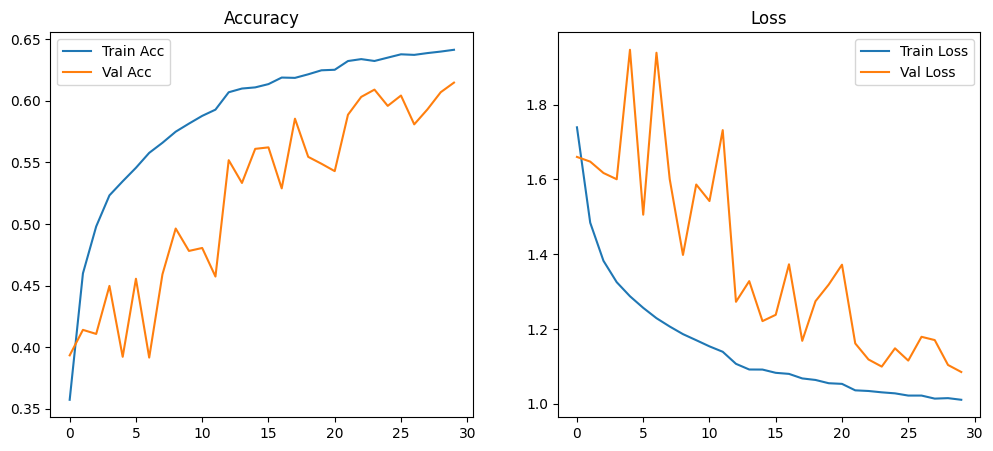

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()
